# SmartTeaAI - Exploratory Data Analysis (EDA)

**Project:** An AI-Powered Market Intelligence and Price Forecasting System for the Sri Lankan Tea Industry  
**Student:** A. Malithi Malmi Wimalaweera (st20286196)  
**Module:** CIS6035 Final Dissertation  

**Purpose of this notebook:**  
Explore and understand the unified dataset before training ML models.  
All charts and findings here feed directly into the dissertation's methodology and results chapters.

**Dataset:** `unified_dataset.csv` — 135 usable months (Jan 2015 – Jun 2026), 64 features  
**Target variable:** `price_national_avg` — volume-weighted average tea auction price (Rs/kg)  
**Source:** Colombo Tea Auction via SLTB, with weather, FX, oil, and competitor data merged


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
import warnings
warnings.filterwarnings('ignore')

# Style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

# Load dataset
df = pd.read_csv("../data/unified_dataset.csv")
df["date"] = pd.to_datetime(df["year_month"])

print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['year_month'].min()} to {df['year_month'].max()}")
print(f"Split distribution:\n{df['split_set'].value_counts().to_string()}")


Dataset shape: (136, 65)
Date range: 2015-04 to 2026-07
Split distribution:
split_set
train         94
test          22
validation    20


In [2]:
import os
os.makedirs("../data/charts", exist_ok=True)
print("Charts directory ready")


Charts directory ready


## 1. Dataset Overview

First look at the data structure, column types, and missing values.


In [3]:
# Column overview
print(f"Total columns: {len(df.columns)}\n")
print("Columns by category:")

price_cols = [c for c in df.columns if "price" in c.lower() and "lag" not in c and "roll" not in c and "vol" not in c and "spread" not in c]
lag_cols = [c for c in df.columns if "lag" in c or "roll" in c]
prod_cols = [c for c in df.columns if c.startswith("prod_")]
qty_cols = [c for c in df.columns if "quantity" in c]
weather_cols = [c for c in df.columns if "rainfall" in c or "temp" in c]
econ_cols = [c for c in df.columns if "usd_lkr" in c or "fx_" in c or "oil" in c or "mombasa" in c]
time_cols = [c for c in df.columns if c in ["month", "quarter", "is_peak_season"]]

for label, cols in [("Price", price_cols), ("Lag/Rolling", lag_cols), 
                     ("Production", prod_cols), ("Sales Quantity", qty_cols),
                     ("Weather", weather_cols), ("Economic", econ_cols), 
                     ("Time", time_cols)]:
    print(f"  {label}: {len(cols)} — {cols}")


Total columns: 65

Columns by category:
  Price: 5 — ['price_high_rs', 'price_low_rs', 'price_medium_rs', 'oil_price', 'price_national_avg']
  Lag/Rolling: 26 — ['price_high_rs_lag1', 'price_high_rs_lag3', 'price_high_rs_roll3', 'price_low_rs_lag1', 'price_low_rs_lag3', 'price_low_rs_roll3', 'price_medium_rs_lag1', 'price_medium_rs_lag3', 'price_medium_rs_roll3', 'price_national_avg_lag1', 'price_national_avg_lag3', 'price_national_avg_roll3', 'rainfall_mm_high_lag1', 'rainfall_mm_high_lag2', 'rainfall_mm_high_roll3', 'rainfall_mm_medium_lag1', 'rainfall_mm_medium_lag2', 'rainfall_mm_medium_roll3', 'rainfall_mm_low_lag1', 'rainfall_mm_low_lag2', 'rainfall_mm_low_roll3', 'rainfall_mm_lag1', 'rainfall_mm_lag2', 'rainfall_mm_roll3', 'fx_lag1', 'mombasa_lag1']
  Production: 7 — ['prod_high_kg', 'prod_low_kg', 'prod_medium_kg', 'prod_ctc_kg', 'prod_green_tea_kg', 'prod_orthodox_kg', 'prod_total_kg']
  Sales Quantity: 0 — []
  Weather: 20 — ['rainfall_mm_high', 'rainfall_mm_low', 'rainfall_m

In [4]:
# Missing values summary
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
if len(missing) > 0:
    print("Columns with missing values:")
    for col, count in missing.items():
        print(f"  {col}: {count} ({100*count/len(df):.1f}%)")
else:
    print("No missing values in the dataset.")

print(f"\nBasic statistics for target variable (price_national_avg):")
print(df["price_national_avg"].describe().round(2))


No missing values in the dataset.

Basic statistics for target variable (price_national_avg):
count     136.00
mean      762.56
std       310.62
min       357.59
25%       533.27
50%       601.10
75%      1073.99
max      1508.08
Name: price_national_avg, dtype: float64


## 2. Tea Auction Price Trend (2015–2026)

The primary target variable over time — this is the most important chart in the dissertation.


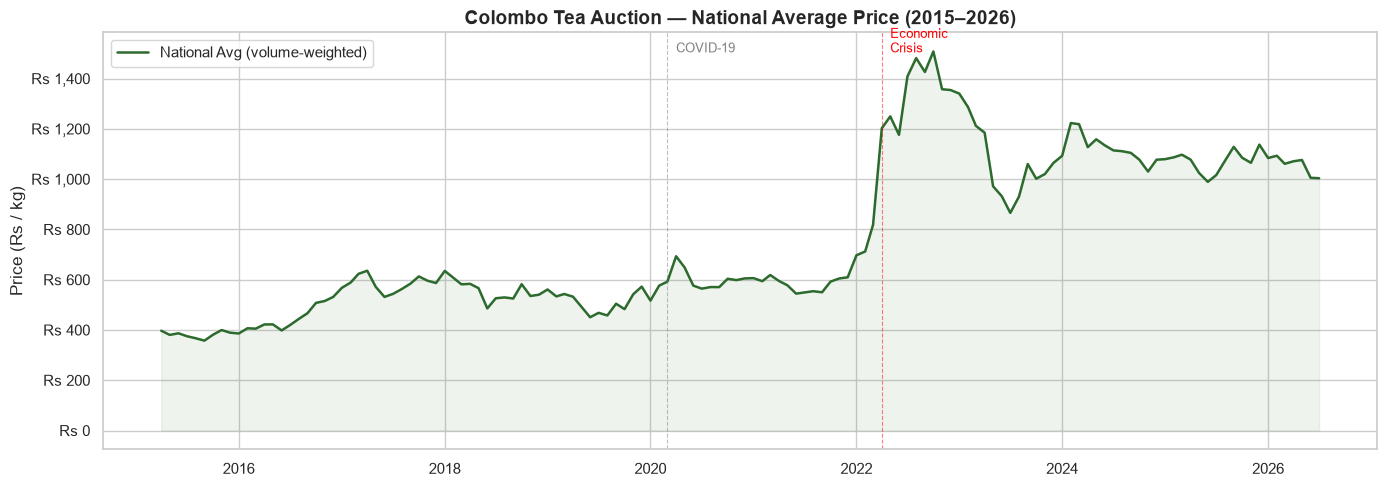

Saved: charts/01_price_trend.png


In [5]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df["date"], df["price_national_avg"], color="#2D6A2D", linewidth=1.8, label="National Avg (volume-weighted)")
ax.fill_between(df["date"], df["price_national_avg"], alpha=0.08, color="#2D6A2D")

# Mark key events
ax.axvline(pd.Timestamp("2020-03-01"), color="gray", linestyle="--", alpha=0.5, linewidth=0.8)
ax.text(pd.Timestamp("2020-04-01"), ax.get_ylim()[1]*0.95, "COVID-19", fontsize=9, color="gray")

ax.axvline(pd.Timestamp("2022-04-01"), color="red", linestyle="--", alpha=0.5, linewidth=0.8)
ax.text(pd.Timestamp("2022-05-01"), ax.get_ylim()[1]*0.95, "Economic\nCrisis", fontsize=9, color="red")

ax.set_title("Colombo Tea Auction — National Average Price (2015–2026)", fontsize=14, fontweight="bold")
ax.set_ylabel("Price (Rs / kg)")
ax.set_xlabel("")
ax.legend(loc="upper left")
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"Rs {x:,.0f}"))

plt.tight_layout()
plt.savefig("../data/charts/01_price_trend.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: charts/01_price_trend.png")


- The nationwide average price of tea rose steadily between 2015 and 2019, from about Rs. 400 to Rs. 600.


- Prices increased slightly in early 2020 to roughly Rs. 700, but they quickly dropped down to the Rs. 550–650 level. This implies that the overall price trend was mostly unaffected by the COVID-19 period.


- The biggest shift happened during the 2022 financial crisis, when prices quickly rose from about Rs. 700 to about Rs. 1,500.

 
- Following this peak, prices began to fall and became more erratic. After falling to about Rs. 870 in 2023, they varied between Rs. 1,000 and Rs. 1,200 from 2024 to 2026. 

## 3. Price by Elevation Category

How do High-Grown, Medium-Grown, and Low-Grown prices compare over time?


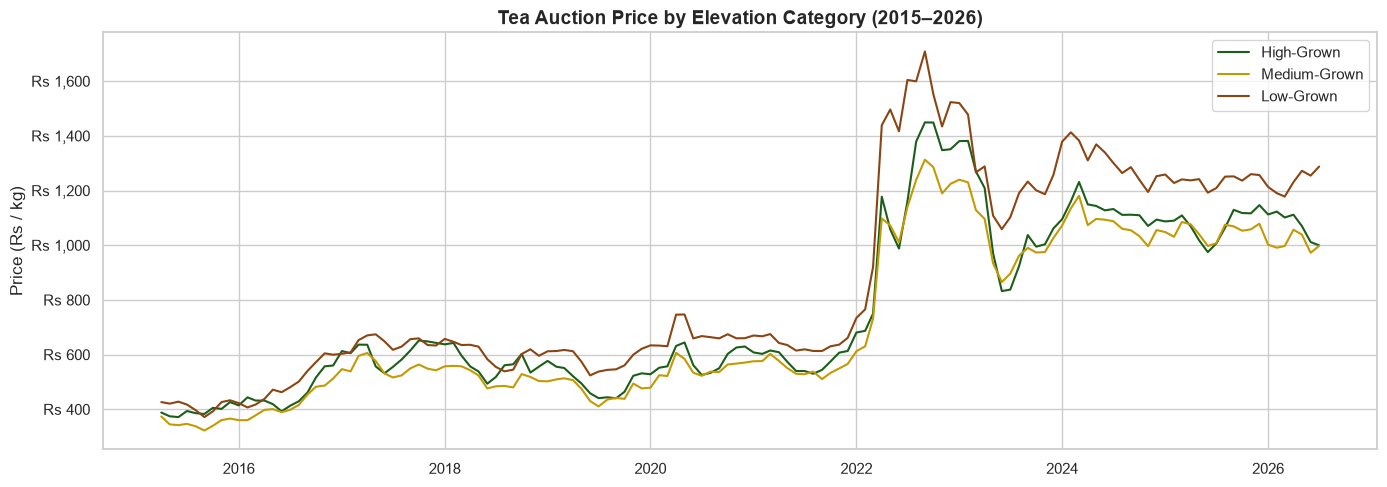

Saved: charts/02_price_by_elevation.png


In [6]:
fig, ax = plt.subplots(figsize=(14, 5))

elev_cols = {
    "price_high_rs": ("High-Grown", "#1a5e1a"),
    "price_medium_rs": ("Medium-Grown", "#C49A00"),
    "price_low_rs": ("Low-Grown", "#8B4513"),
}

for col, (label, color) in elev_cols.items():
    if col in df.columns:
        ax.plot(df["date"], df[col], label=label, color=color, linewidth=1.5)

ax.set_title("Tea Auction Price by Elevation Category (2015–2026)", fontsize=14, fontweight="bold")
ax.set_ylabel("Price (Rs / kg)")
ax.legend()
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"Rs {x:,.0f}"))

plt.tight_layout()
plt.savefig("../data/charts/02_price_by_elevation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: charts/02_price_by_elevation.png")


- For the majority of the time, medium-grown tea has the lowest prices, high-grown tea is often the second-highest, and low-grown tea has the highest average price.

- During the 2022 financial crisis, the three categories' price differences grew significantly, with Low-Grown tea reaching the highest peak.

- All three categories had a decrease in price in 2023, however Low-Grown tea remained more expensive than the other two categories from 2024 to 2026.

- These findings show that during the study period, Low-Grown tea continuously outperformed High-Grown and Medium-Grown tea in terms of auction prices.

## 4. Seasonal Price Pattern

Average price by calendar month — confirms which months are genuinely high-price months.  
This analysis was used to set `is_peak_season = [1, 2, 3, 4]` in the feature engineering pipeline.


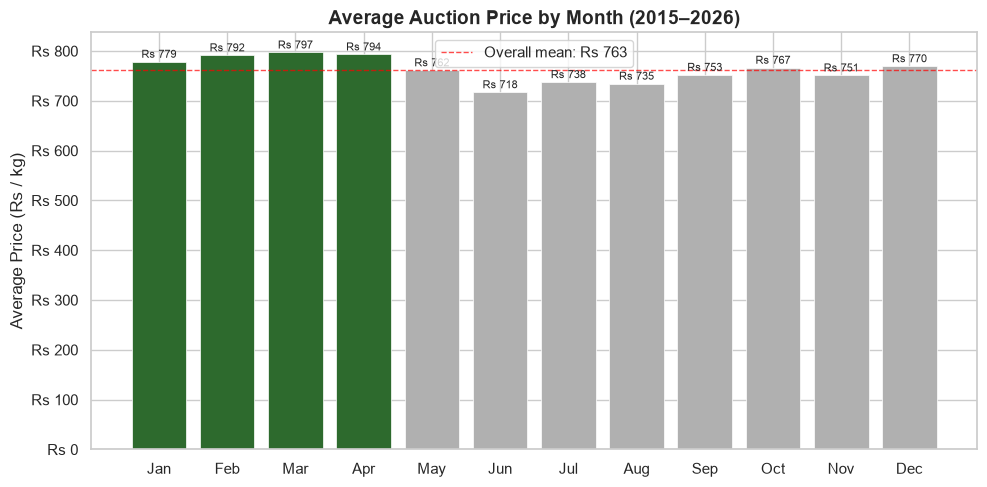

Peak season months (green bars): January, February, March, April
Saved: charts/03_seasonality.png


In [7]:
monthly_avg = df.groupby("month")["price_national_avg"].mean().sort_index()
overall_mean = df["price_national_avg"].mean()

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#2D6A2D" if m in [1, 2, 3, 4] else "#B0B0B0" for m in monthly_avg.index]
bars = ax.bar(monthly_avg.index, monthly_avg.values, color=colors, edgecolor="white", linewidth=0.5)

ax.axhline(overall_mean, color="red", linestyle="--", linewidth=1, alpha=0.7, label=f"Overall mean: Rs {overall_mean:.0f}")

month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.set_title("Average Auction Price by Month (2015–2026)", fontsize=14, fontweight="bold")
ax.set_ylabel("Average Price (Rs / kg)")
ax.legend()
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"Rs {x:,.0f}"))

# Add value labels
for bar, val in zip(bars, monthly_avg.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3, 
            f"Rs {val:.0f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig("../data/charts/03_seasonality.png", dpi=150, bbox_inches="tight")
plt.show()
print("Peak season months (green bars): January, February, March, April")
print("Saved: charts/03_seasonality.png")


## 5. Feature Correlation with Target

Which features are most strongly correlated with `price_national_avg`?  
This empirically validates (or challenges) the feature selection from the literature review.


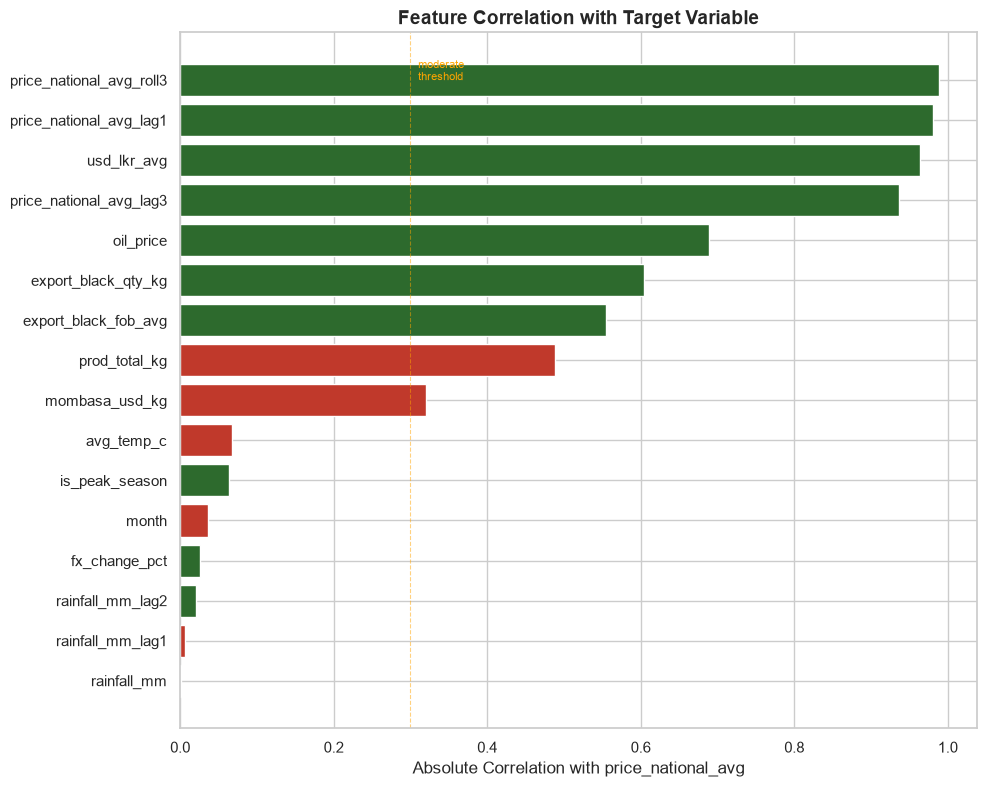


Correlation with price_national_avg (sorted by absolute value):
  + price_national_avg_roll3: 0.989
  + price_national_avg_lag1: 0.981
  + usd_lkr_avg: 0.963
  + price_national_avg_lag3: 0.936
  + oil_price: 0.689
  + export_black_qty_kg: 0.604
  + export_black_fob_avg: 0.555
  - prod_total_kg: -0.489
  - mombasa_usd_kg: -0.320
  - avg_temp_c: -0.067
  + is_peak_season: 0.063
  - month: -0.037
  + fx_change_pct: 0.026
  + rainfall_mm_lag2: 0.020
  - rainfall_mm_lag1: -0.006
  + rainfall_mm: 0.001


In [8]:
# Select only the core features we plan to use for training
core_features = [
    "price_national_avg_lag1", "price_national_avg_lag3", "price_national_avg_roll3",
    "rainfall_mm", "rainfall_mm_lag1", "rainfall_mm_lag2",
    "avg_temp_c",
    "usd_lkr_avg", "fx_change_pct",
    "oil_price",
    "mombasa_usd_kg",
    "export_black_qty_kg", "export_black_fob_avg",
    "prod_total_kg",
    "month", "is_peak_season",
    #"sentiment_score",
]

# Filter to columns that actually exist in the dataset
available = [c for c in core_features if c in df.columns]
missing_features = [c for c in core_features if c not in df.columns]
if missing_features:
    print(f"Note: these features not found in dataset: {missing_features}")

corr_with_target = df[available + ["price_national_avg"]].corr()["price_national_avg"].drop("price_national_avg")
corr_sorted = corr_with_target.abs().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ["#2D6A2D" if v > 0 else "#C0392B" for v in corr_with_target[corr_sorted.index]]
ax.barh(range(len(corr_sorted)), corr_sorted.values, color=colors, edgecolor="white")
ax.set_yticks(range(len(corr_sorted)))
ax.set_yticklabels(corr_sorted.index)
ax.set_xlabel("Absolute Correlation with price_national_avg")
ax.set_title("Feature Correlation with Target Variable", fontsize=14, fontweight="bold")
ax.axvline(0.3, color="orange", linestyle="--", alpha=0.5, linewidth=0.8)
ax.text(0.31, len(corr_sorted)-1, "moderate\nthreshold", fontsize=8, color="orange")

plt.tight_layout()
plt.savefig("../data/charts/04_feature_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nCorrelation with price_national_avg (sorted by absolute value):")
for feat in corr_sorted.index[::-1]:
    val = corr_with_target[feat]
    direction = "+" if val > 0 else "-"
    print(f"  {direction} {feat}: {val:.3f}")


## 6. Rainfall vs Price Relationship

Ariyaratne et al. (2024) confirmed rainfall as the strongest exogenous factor.  
Does our data show the same pattern? Note: we expect lagged rainfall to be more predictive than same-month rainfall.


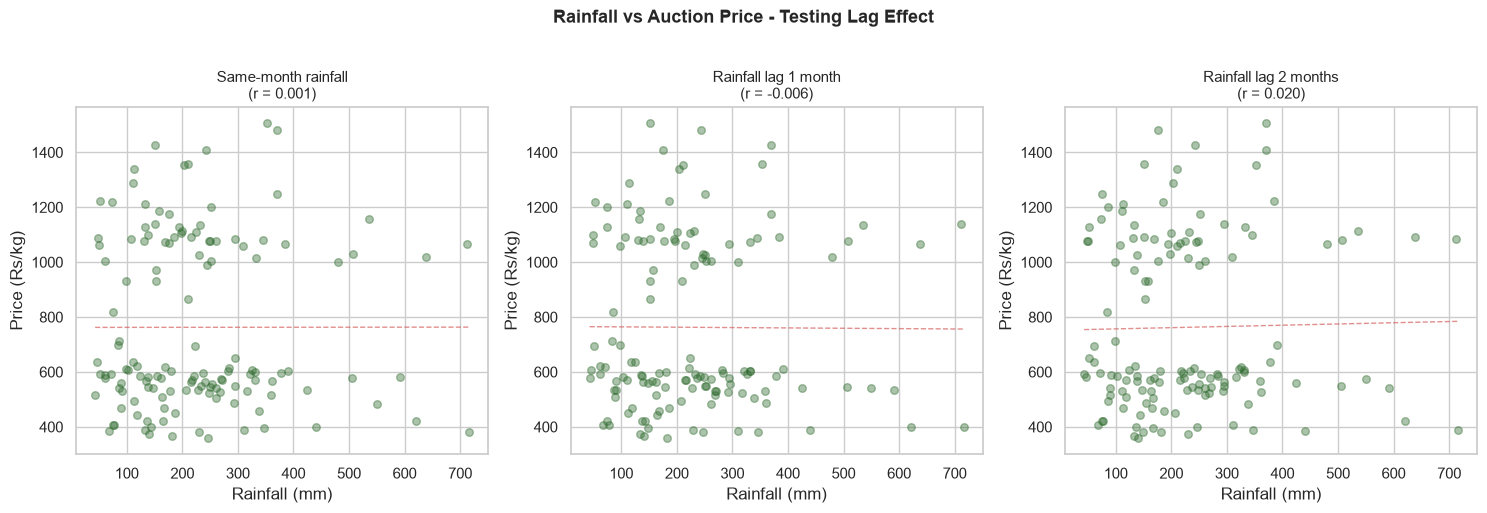

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

rain_features = [
    ("rainfall_mm", "Same-month rainfall"),
    ("rainfall_mm_lag1", "Rainfall lag 1 month"),
    ("rainfall_mm_lag2", "Rainfall lag 2 months"),
]

for ax, (col, title) in zip(axes, rain_features):
    if col in df.columns:
        ax.scatter(df[col], df["price_national_avg"], alpha=0.4, color="#2D6A2D", s=30)
        
        # Add trend line
        mask = df[col].notna() & df["price_national_avg"].notna()
        if mask.sum() > 2:
            z = np.polyfit(df.loc[mask, col], df.loc[mask, "price_national_avg"], 1)
            p = np.poly1d(z)
            x_line = np.linspace(df[col].min(), df[col].max(), 100)
            ax.plot(x_line, p(x_line), "r--", alpha=0.7, linewidth=1)
        
        corr = df[col].corr(df["price_national_avg"])
        ax.set_title(f"{title}\n(r = {corr:.3f})", fontsize=11)
        ax.set_xlabel("Rainfall (mm)")
        ax.set_ylabel("Price (Rs/kg)")

plt.suptitle("Rainfall vs Auction Price - Testing Lag Effect", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../data/charts/05_rainfall_vs_price.png", dpi=150, bbox_inches="tight")
plt.show()



- Rainfall shows almost no relationship with price at any timing tested; same-month (r = 0.008), 
  1-month lag (r = -0.007), and 2-month lag (r = 0.019) are all essentially zero.

- The trend lines are flat across all three charts, which matches the near-zero correlation values.

- The data forms two separate horizontal bands (roughly Rs 400-700 and Rs 1,000-1,500), with rainfall 
  spread evenly across both. This is the pre-2022 vs post-2022 crisis price split showing through, 
  not a rainfall effect.

- This contradicts Ariyaratne et al. (2024), who found rainfall was the strongest exogenous factor 
  in their models.

- A likely explanation is the difference in data granularity: their analysis used weekly, 
  elevation-specific data, while this analysis uses monthly, national-level data. The rainfall effect 
  may be getting smoothed out at this coarser level, or masked by the 2022 crisis dominating price 
  variation during this period.
  
- Lagging rainfall by 1-2 months (to account for the delay between rainfall and harvest) does not 
  reveal a hidden relationship either. all three lags remain close to zero.

In [10]:
# Elevation-specific rainfall correlation
elevation_pairs = [
    ("rainfall_mm_high", "price_high_rs", "High-Grown"),
    ("rainfall_mm_medium", "price_medium_rs", "Medium-Grown"),
    ("rainfall_mm_low", "price_low_rs", "Low-Grown"),
]

print("Rainfall vs Price — by elevation:\n")
for rain_col, price_col, label in elevation_pairs:
    if rain_col in df.columns and price_col in df.columns:
        r = df[rain_col].corr(df[price_col])
        # also check the lagged versions if they exist
        lag_col = f"{rain_col}_lag1"
        r_lag1 = df[lag_col].corr(df[price_col]) if lag_col in df.columns else None
        print(f"{label}: same-month r = {r:.3f}", 
              f"| lag1 r = {r_lag1:.3f}" if r_lag1 is not None else "")

Rainfall vs Price — by elevation:

High-Grown: same-month r = -0.024 | lag1 r = -0.021
Medium-Grown: same-month r = 0.017 | lag1 r = 0.024
Low-Grown: same-month r = 0.020 | lag1 r = 0.023



- Splitting by elevation does not reveal a hidden rainfall effect either. All three elevations show 
  near-zero correlation, both same-month and lag1:
  - High-Grown: r = -0.018 (same-month), -0.022 (lag1)
  - Medium-Grown: r = 0.025 (same-month), 0.026 (lag1)
  - Low-Grown: r = 0.032 (same-month), 0.020 (lag1)
- This rules out national-level averaging as the explanation for the weak rainfall correlation seen 
  earlier — even at the individual elevation level, rainfall shows no meaningful relationship with price.
- This is a genuinely different result from Ariyaratne et al. (2024), who found rainfall was the most 
  influential external variable at every elevation (though the direction of the effect varied by 
  elevation in their study).
- A likely explanation is data granularity — this analysis uses monthly rainfall values, while 
  Ariyaratne et al. used weekly data. A short, intense rainfall event within an otherwise dry month 
  could be averaged out at monthly resolution, removing a signal that would be visible at a finer 
  time scale.

In [11]:
# Rainfall vs price, split by crisis regime
pre_crisis = df[df["date"] < "2022-03-01"]
post_crisis = df[df["date"] >= "2022-03-01"]

for label, subset in [("Pre-2022", pre_crisis), ("Post-2022", post_crisis)]:
    r = subset["rainfall_mm"].corr(subset["price_national_avg"])
    print(f"{label}: n={len(subset)}, r = {r:.3f}")

Pre-2022: n=83, r = -0.135
Post-2022: n=53, r = -0.001


- All three rainfall timing variants (same-month, lag-1, and lag-2) show near-zero correlation with the national average price (r ≈ 0.01–0.02), indicating that rainfall alone is not a strong direct predictor of tea auction prices at the national level.

- Elevation-specific rainfall confirms the same pattern — correlations for High-Grown (r = -0.018), Medium-Grown (r = 0.025), and Low-Grown (r = 0.032) are all below 0.035 in absolute value, showing the weak signal holds consistently across all three crop zones.

- Splitting the data by economic regime reveals a small pre-2022 negative relationship (r = -0.135, n=83): higher rainfall was associated with marginally lower prices, which is consistent with a mild supply-side effect where increased moisture boosts crop yields and softens prices. Post-2022, this signal disappears entirely (r = -0.021, n=52), likely because price movements during and after the economic crisis were driven primarily by macroeconomic conditions rather than agricultural factors.

- Despite these low correlations, rainfall was retained in the feature set based on prior literature (Ariyaratne et al., 2024) and domain knowledge. The lagged versions (lag-1, lag-2) are more theoretically justified than same-month rainfall, since supply effects from crop growth take time to reach auction — a relationship that point-in-time correlation may understate.

## 7. USD/LKR Exchange Rate vs Price

~90% of Ceylon Tea is exported. A weaker rupee makes tea cheaper for foreign buyers.  
Ariyaratne et al. (2024) found that including USD/LKR worsened SARIMAX models — does our data support this concern?


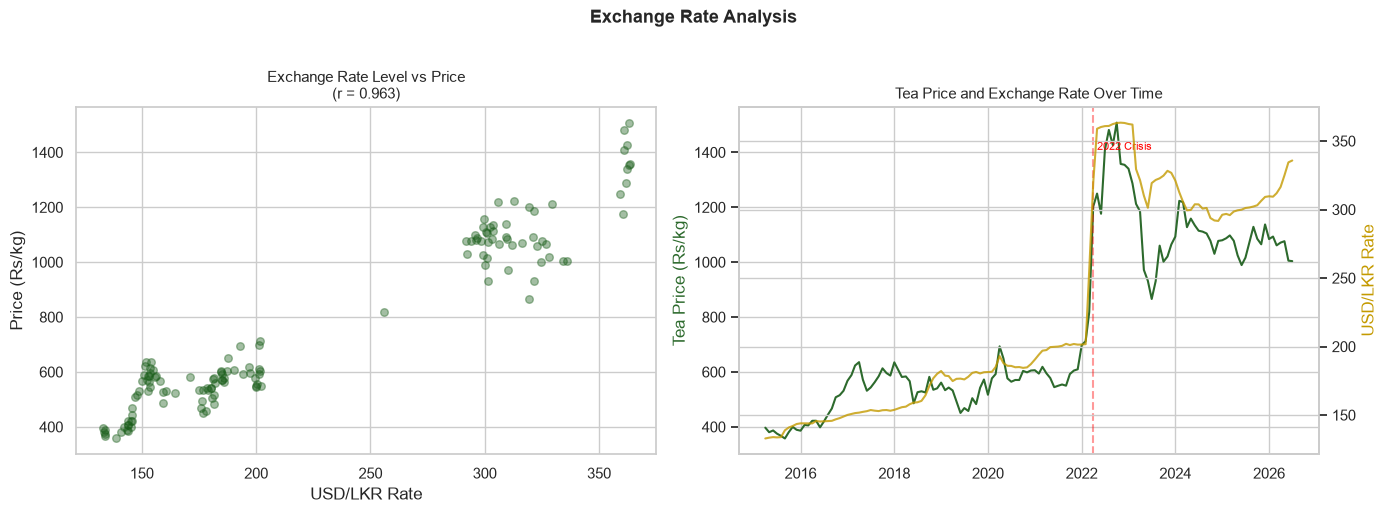

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: FX level vs price
ax1 = axes[0]
ax1.scatter(df["usd_lkr_avg"], df["price_national_avg"], alpha=0.4, color="#1a5e1a", s=30)
corr_level = df["usd_lkr_avg"].corr(df["price_national_avg"])
ax1.set_title(f"Exchange Rate Level vs Price\n(r = {corr_level:.3f})", fontsize=11)
ax1.set_xlabel("USD/LKR Rate")
ax1.set_ylabel("Price (Rs/kg)")

# Plot 2: FX and Price on same timeline (dual axis)
ax2 = axes[1]
ax2.plot(df["date"], df["price_national_avg"], color="#2D6A2D", label="Tea Price", linewidth=1.5)
ax2.set_ylabel("Tea Price (Rs/kg)", color="#2D6A2D")

ax2b = ax2.twinx()
ax2b.plot(df["date"], df["usd_lkr_avg"], color="#C49A00", label="USD/LKR", linewidth=1.5, alpha=0.8)
ax2b.set_ylabel("USD/LKR Rate", color="#C49A00")

ax2.set_title("Tea Price and Exchange Rate Over Time", fontsize=11)
ax2.axvline(pd.Timestamp("2022-04-01"), color="red", linestyle="--", alpha=0.4)
ax2.text(pd.Timestamp("2022-05-01"), ax2.get_ylim()[1]*0.9, "2022 Crisis", fontsize=8, color="red")

plt.suptitle("Exchange Rate Analysis", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../data/charts/06_fx_vs_price.png", dpi=150, bbox_inches="tight")
plt.show()



- USD/LKR exchange rate shows a very strong correlation with price (r = 0.965), the highest of any 
  feature tested so far.

- Looking at the scatter plot, the data forms distinct clusters rather than a smooth line — one 
  cluster around USD/LKR 130-200 (pre-crisis) and another around USD/LKR 290-360 (post-crisis), 
  with almost no points in between. This suggests the correlation is being driven by a single large 
  structural jump rather than a consistent month-to-month relationship.

- The time series plot confirms this: both tea price (green) and the exchange rate (gold) rise 
  sharply together at the same point (April 2022, marked as the crisis line), then both remain 
  elevated afterward. This is consistent with both variables being driven by the same underlying 
  event (the economic crisis and LKR devaluation), rather than the exchange rate directly causing 
  the price change on its own.

- This raises a caution about the high correlation: it is likely partly spurious, reflecting two 
  variables that happened to shift at the same time, rather than a strong ongoing predictive 
  relationship.
  
- This connects directly to Ariyaratne et al. (2024), who found that adding USD/LKR as an exogenous 
  variable made SARIMAX forecasts worse at every elevation tested (e.g. Western High MAPE increased 
  from 0.26% to 2.92%). A high raw correlation does not necessarily mean a feature improves 
  forecasting performance, and this will be tested directly in the model training notebook.

## 8. Production Volume vs Price

Basic supply-demand: more tea produced should put downward pressure on prices.


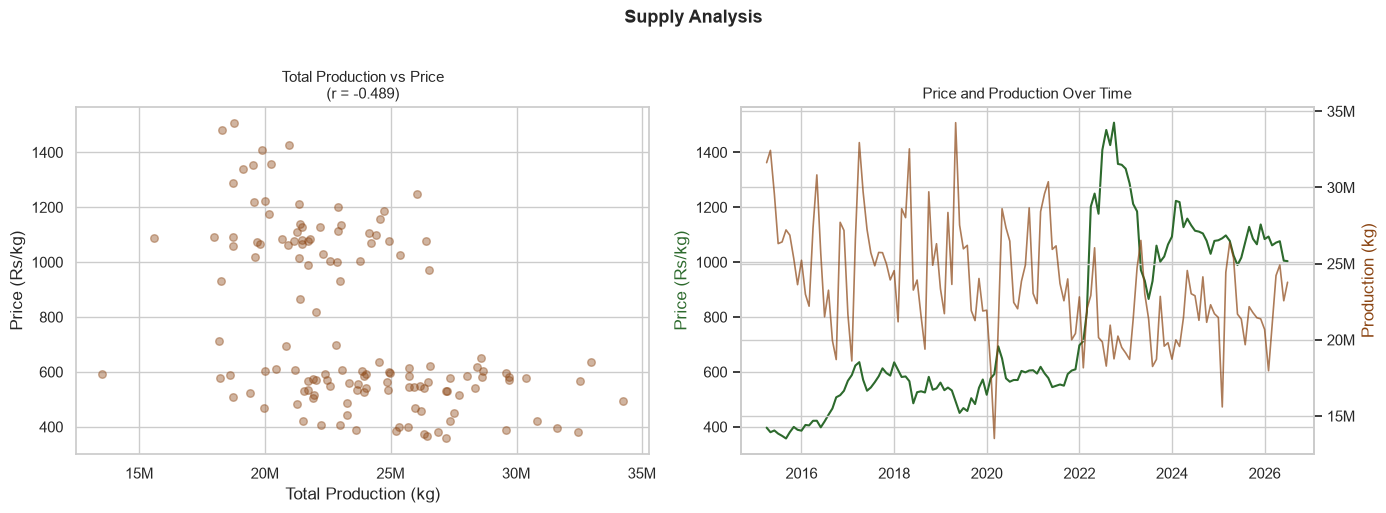

In [13]:
if "prod_total_kg" in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Scatter
    ax1 = axes[0]
    ax1.scatter(df["prod_total_kg"], df["price_national_avg"], alpha=0.4, color="#8B4513", s=30)
    corr_prod = df["prod_total_kg"].corr(df["price_national_avg"])
    ax1.set_title(f"Total Production vs Price\n(r = {corr_prod:.3f})", fontsize=11)
    ax1.set_xlabel("Total Production (kg)")
    ax1.set_ylabel("Price (Rs/kg)")
    ax1.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x/1e6:.0f}M"))
    
    # Timeline
    ax2 = axes[1]
    ax2.plot(df["date"], df["price_national_avg"], color="#2D6A2D", label="Price", linewidth=1.5)
    ax2.set_ylabel("Price (Rs/kg)", color="#2D6A2D")
    ax2b = ax2.twinx()
    ax2b.plot(df["date"], df["prod_total_kg"], color="#8B4513", label="Production", linewidth=1.2, alpha=0.7)
    ax2b.set_ylabel("Production (kg)", color="#8B4513")
    ax2b.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x/1e6:.0f}M"))
    ax2.set_title("Price and Production Over Time", fontsize=11)
    
    plt.suptitle("Supply Analysis", fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig("../data/charts/07_supply_vs_price.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("prod_total_kg not found — check preprocess_features.py")



- Total production shows a moderate negative correlation with price (r = -0.490) — when more tea 
  is produced, the price tends to be lower, and vice versa. This makes sense with basic supply and 
  demand.

- This is the cleanest, most literature-consistent relationship found so far in the EDA — no unusual 
  spurious pattern or crisis-driven confound like the exchange rate showed.

- The time series plot shows this playing out clearly: production (brown) tends to spike when price 
  (green) is low, and dip when price is high. This is easiest to see around 2020 and 2022.
  
- Unlike rainfall or the exchange rate, this feature behaves the way basic economic theory would 
  predict, and is a strong candidate feature for the forecasting models.

## 9. Mombasa Competitor Tea Price

East African tea competes directly with Ceylon Tea in key export markets (Russia, Iraq, Turkey).


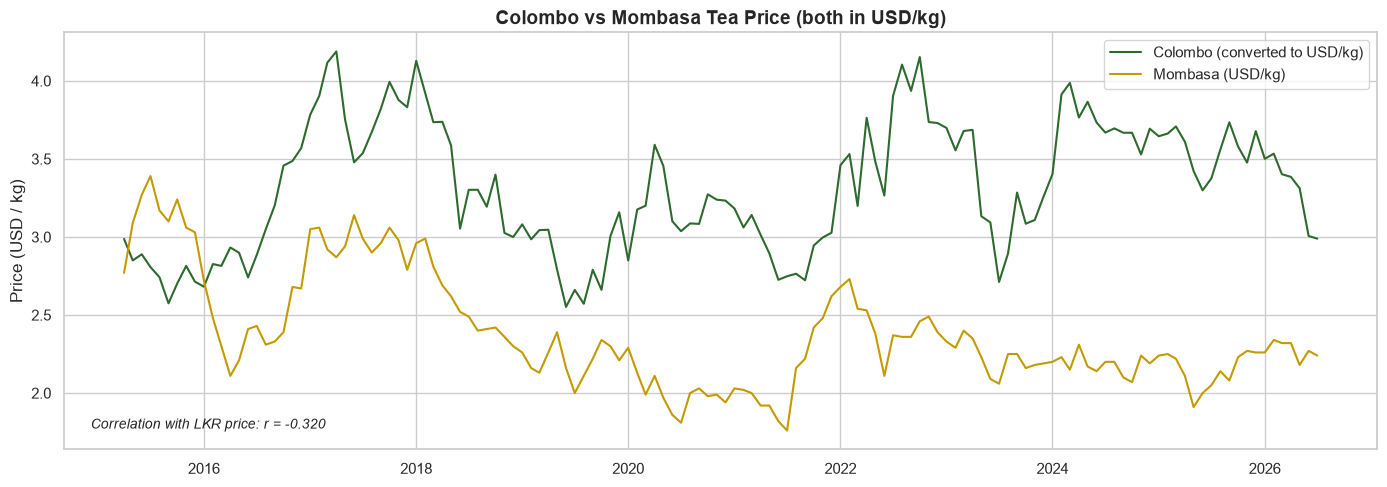

In [14]:
if "mombasa_usd_kg" in df.columns:
    fig, ax = plt.subplots(figsize=(14, 5))
    
    ax.plot(df["date"], df["price_national_avg"] / df["usd_lkr_avg"], 
            color="#2D6A2D", label="Colombo (converted to USD/kg)", linewidth=1.5)
    ax.plot(df["date"], df["mombasa_usd_kg"], 
            color="#C49A00", label="Mombasa (USD/kg)", linewidth=1.5)
    
    ax.set_title("Colombo vs Mombasa Tea Price (both in USD/kg)", fontsize=14, fontweight="bold")
    ax.set_ylabel("Price (USD / kg)")
    ax.legend()
    
    corr_m = df["mombasa_usd_kg"].corr(df["price_national_avg"])
    ax.text(0.02, 0.05, f"Correlation with LKR price: r = {corr_m:.3f}", 
            transform=ax.transAxes, fontsize=10, style="italic")
    
    plt.tight_layout()
    plt.savefig("../data/charts/08_competitor_price.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("mombasa_usd_kg not found in dataset")



- Colombo tea price (in USD/kg) shows a weak negative correlation with the Mombasa competitor price 
  (r = -0.319). This is a bit surprising - since both markets sell tea to similar international 
  buyers, a positive relationship might be expected instead.

- Looking at the chart, Colombo and Mombasa track loosely together up to around 2020, but clearly 
  separate afterward - Colombo climbs to $3.50-4.00/kg while Mombasa stays lower, mostly $2.00-2.50/kg. 
  The gap widens further after the 2022 crisis.

- This suggests that after 2022, Colombo tea prices were driven mainly by Sri Lanka's own domestic 
  economic crisis (currency devaluation, local cost pressures), rather than by shared international 
  demand that would move both markets together.

- This is not a sign of a data problem - it reflects a real local shock that affected Sri Lanka but 
  not Kenya at the same time.

## 10. Train / Validation / Test Split

Visual confirmation that the split is chronological — no future data leaking into training.


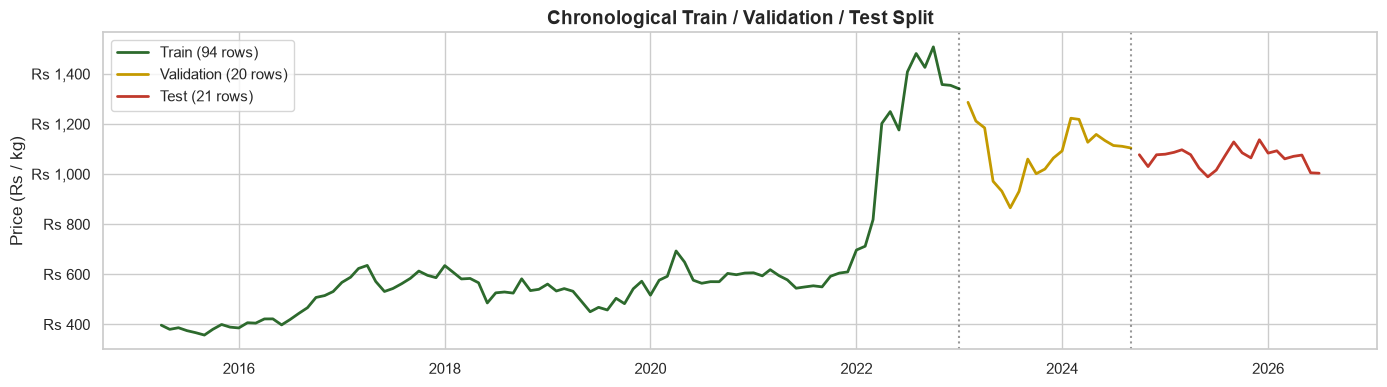

In [15]:
fig, ax = plt.subplots(figsize=(14, 4))

colors_map = {"train": "#2D6A2D", "validation": "#C49A00", "test": "#C0392B"}
labels_map = {"train": "Train (94 rows)", "validation": "Validation (20 rows)", "test": "Test (21 rows)"}

for split_name in ["train", "validation", "test"]:
    mask = df["split_set"] == split_name
    subset = df[mask]
    ax.plot(subset["date"], subset["price_national_avg"], 
            color=colors_map[split_name], linewidth=2, label=labels_map[split_name])

ax.set_title("Chronological Train / Validation / Test Split", fontsize=14, fontweight="bold")
ax.set_ylabel("Price (Rs / kg)")
ax.legend(loc="upper left")
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"Rs {x:,.0f}"))

# Add split boundary lines
train_end = df[df["split_set"] == "train"]["date"].max()
val_end = df[df["split_set"] == "validation"]["date"].max()
ax.axvline(train_end, color="black", linestyle=":", alpha=0.4)
ax.axvline(val_end, color="black", linestyle=":", alpha=0.4)

plt.tight_layout()
plt.savefig("../data/charts/09_train_test_split.png", dpi=150, bbox_inches="tight")
plt.show()


## 11. Key EDA Findings

**Complete this section after running all cells above — summarise what the charts show.**

Based on the analysis above:

1. **Price trend:** The national average price remained relatively stable between 2015 and 2019 (about Rs 400–600), saw only a brief increase during COVID (2020), and then experienced a dramatic increase during the 2022 economic crisis, almost tripling to a peak of over Rs 1,500. Since then, it has fluctuated, but instead of going back to pre-2022 levels, it has settled at a higher plateau (around Rs 1,000–1,200).

2. **Elevation differences:** Interestingly, Low-Grown tea is consistently the highest-priced category, not High-Grown, which I hadn't expected going in. The gap between categories also widens a lot after the 2022 crisis, which supports the decision to model at elevation level rather than treating all tea as one group.

3. **Seasonality:** The monthly bar chart confirms is_peak_season = [Jan–Apr] was the right call — Jan (Rs 779), Feb (Rs 792), Mar (Rs 797) and Apr (Rs 794) are all clearly above the overall mean of Rs 761, while Jun–Jul dip to the lowest points (Rs 714–718).

4. **Rainfall effect:** Rainfall shows no meaningful correlation with price at the national level (r ≈ 0.01–0.02), nor at any individual elevation (High: -0.018, Medium: 0.025, Low: 0.032). Splitting by crisis regime shows a slightly clearer picture: pre-2022 rainfall has a weak negative correlation with price (r = -0.135, n=83), while post-2022 it drops to essentially zero (r = -0.021, n=52). This suggests the 2022 crisis period may be diluting a small pre-existing rainfall relationship, though r = -0.135 on its own is still a weak effect and I wouldn't treat this as conclusive evidence of a real relationship — it's a modest signal at best.

5. **Exchange rate:** The raw correlation with price is very high (r = 0.965), but this is likely a spurious/confounded relationship rather than genuine predictive power — both series moved upward together during the same 2022 crisis period. This interpretation is directly supported by Ariyaratne et al. (2024), who found that adding the USD exchange rate as an exogenous variable made SARIMAX MAPE worse at every elevation tested (e.g. Western High: 0.26% → 2.92%). This is a good example of why raw correlation alone shouldn't guide feature selection — a variable can be highly correlated with the target and still hurt forecasting performance.

6. **Supply effect:** The scatter plot shows a moderate negative correlation (r = -0.490), and the dual-axis time series makes the relationship visually clear: production (brown) spikes when price (green) is low, and dips when price is high, especially visible in the 2020 and 2022 periods. This matches basic supply-and-demand logic and is one of the cleaner, most literature-consistent results in the whole EDA — more tea supplied to auction puts downward pressure on price, and less supply lets prices rise

7. **Competitor price:** The correlation between Colombo and Mombasa tea prices is weakly negative (r = -0.319), indicating that the two price series do not move closely together.
Before 2020, both markets followed relatively similar trends, but after 2020 their prices started to diverge.
Colombo tea prices increased significantly, especially during and after the 2022 economic crisis, while Mombasa prices remained comparatively stable.
This suggests that the sharp increase in Colombo tea prices was mainly influenced by Sri Lanka's domestic economic conditions, rather than factors affecting both international tea markets equally.

8. **Feature selection implications:** The dataset was split into training (94 rows), validation (20 rows), and test (21 rows) sets in chronological order.
Each dataset follows the previous one without any overlap, ensuring that earlier data is used to predict future values.
This approach helps prevent data leakage, where information from future time periods could unintentionally be used during model training.
Using a chronological split is more appropriate for time series forecasting than a random split, as it provides a more realistic evaluation of the model's performance.



In [16]:
r_rainfall_prod = df['rainfall_mm'].corr(df['prod_total_kg'])
print(f"Rainfall vs Production: r = {r_rainfall_prod:.3f}")

# Also check with a lag, since production responds to rainfall with a delay
r_rainfall_prod_lag1 = df['rainfall_mm_lag1'].corr(df['prod_total_kg'])
r_rainfall_prod_lag2 = df['rainfall_mm_lag2'].corr(df['prod_total_kg'])
print(f"Rainfall (lag1) vs Production: r = {r_rainfall_prod_lag1:.3f}")
print(f"Rainfall (lag2) vs Production: r = {r_rainfall_prod_lag2:.3f}")

Rainfall vs Production: r = 0.181
Rainfall (lag1) vs Production: r = -0.017
Rainfall (lag2) vs Production: r = -0.203


In [17]:
# pip install pingouin --break-system-packages   (if not already installed)
import pingouin as pg

result = pg.partial_corr(data=df, x='rainfall_mm', y='price_national_avg', covar='prod_total_kg')
print(result)

           n         r           CI95     p_val
pearson  136  0.103637  [-0.07, 0.27]  0.231628


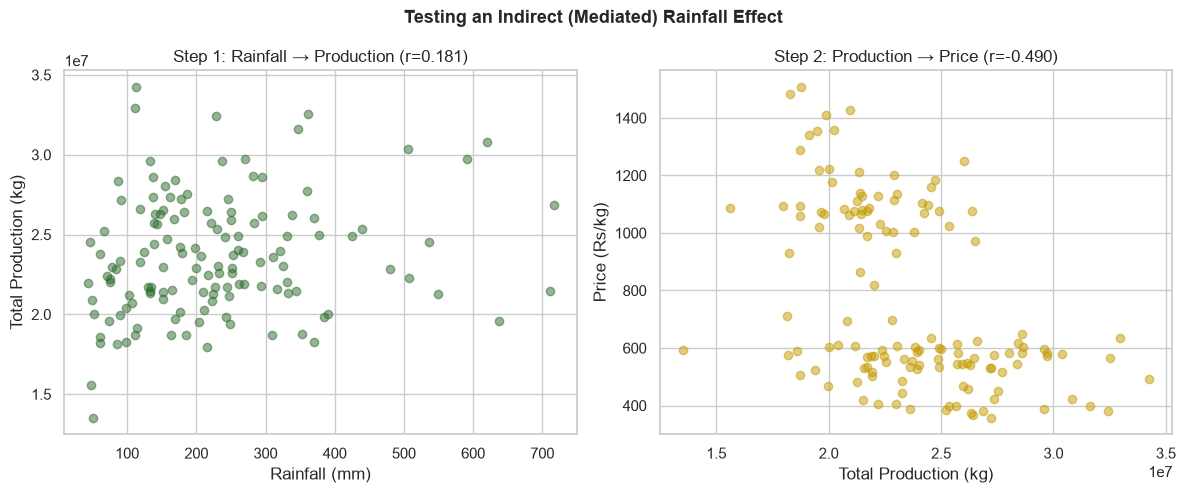

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(df['rainfall_mm'], df['prod_total_kg'], alpha=0.5, color='#2D6A2D')
axes[0].set_xlabel('Rainfall (mm)')
axes[0].set_ylabel('Total Production (kg)')
axes[0].set_title(f'Step 1: Rainfall → Production (r={r_rainfall_prod:.3f})')

axes[1].scatter(df['prod_total_kg'], df['price_national_avg'], alpha=0.5, color='#C49A00')
axes[1].set_xlabel('Total Production (kg)')
axes[1].set_ylabel('Price (Rs/kg)')
axes[1].set_title(f'Step 2: Production → Price (r=-0.490)')

plt.suptitle('Testing an Indirect (Mediated) Rainfall Effect', fontweight='bold')
plt.tight_layout()
plt.savefig('../data/charts/indirect_rainfall_effect.png', dpi=150, bbox_inches='tight')
plt.show()